# SignalScope UZ — reproducible submission notebook (team `SSUZ7K`)

**Task.** Estimate the probability that each alert (`signal_id`) in the hidden test set is escalated
(`eskalatsiya = 1`), from the customer's transaction history. Metric: ROC-AUC.

**Approach.** One feature row per alert, built only from transactions strictly *before* the alert date
(aggregates per type × direction, 1–90-day windows, amount histograms, last-20 transactions, the pre-alert burst).
Tuned LightGBM / XGBoost / CatBoost / logistic regression are evaluated with repeated stratified 5-fold CV
(5×3, seed 42). The final prediction uses the model set chosen by the fold-wise blend check
(**lgb**), refit on all training rows with 5 seeds, rank-mapped to (0, 1).

**Runtime.** Full run ≈ 10–15 min on a 32-thread CPU (no GPU needed); `FAST_MODE=True` ≈ 2 min.
**Hardware used.** Windows 11, 32 logical CPU cores, 32 GB RAM (GPU present but not used here).

**Inputs.** Only the five provided files in `DATA_DIR`. **Output.** `OUTPUT_DIR/team_SSUZ7K.csv` + an inline validator.

In [1]:
# ---- configuration -------------------------------------------------------------------------------
from pathlib import Path
DATA_DIR = Path("../data/raw") if Path("../data/raw").exists() else Path("data/raw")
# ^ put train_signals.csv, test_signals.csv, train_transactions.parquet, test_transactions.parquet,
#   sample_submission.csv here (paths are relative; no absolute paths needed)
OUTPUT_DIR = Path("outputs_notebook")
TEAM_ID = "SSUZ7K"
SEED = 42
N_JOBS = 16                  # fixed thread count -> deterministic GBDT results
FAST_MODE = False               # True = quick smoke run (1 CV repeat, LightGBM only, 1 seed)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# ---- environment ---------------------------------------------------------------------------------
# pip install numpy==2.2.6 pandas==2.3.3 polars==1.34.0 pyarrow==21.0.0 scipy==1.16.2 scikit-learn==1.7.2 \
#             lightgbm==4.6.0 xgboost==3.0.5 catboost==1.2.8 matplotlib==3.10.6
import os, random, time, warnings, hashlib
os.environ["PYTHONHASHSEED"] = str(SEED)
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, polars as pl
import lightgbm, xgboost, catboost, sklearn, scipy
random.seed(SEED); np.random.seed(SEED)
for m in (np, pd, pl, lightgbm, xgboost, catboost, sklearn, scipy):
    print(f"{m.__name__:12s} {m.__version__}")
T0 = time.time()

numpy        2.2.6
pandas       2.3.3
polars       1.34.0
lightgbm     4.6.0
xgboost      3.0.5
catboost     1.2.8
sklearn      1.7.2
scipy        1.16.2


## 1. Load data and audit

In [3]:
train_sig = pd.read_csv(DATA_DIR / "train_signals.csv", dtype={"signal_id": str}, parse_dates=["signal_sanasi"])
test_sig = pd.read_csv(DATA_DIR / "test_signals.csv", dtype={"signal_id": str}, parse_dates=["signal_sanasi"])
sample = pd.read_csv(DATA_DIR / "sample_submission.csv", dtype={"signal_id": str})
tx_train = pl.read_parquet(DATA_DIR / "train_transactions.parquet")
tx_test = pl.read_parquet(DATA_DIR / "test_transactions.parquet")
print("signals", train_sig.shape, test_sig.shape, "| tx", tx_train.shape, tx_test.shape)
print("escalation rate", round(train_sig.eskalatsiya.mean(), 4))
print("dup ids", train_sig.signal_id.duplicated().sum(), test_sig.signal_id.duplicated().sum(),
      "| nulls", int(train_sig.isna().sum().sum()), int(tx_train.null_count().sum_horizontal()[0]))
print("date range train", train_sig.signal_sanasi.min().date(), train_sig.signal_sanasi.max().date(),
      "| test", test_sig.signal_sanasi.min().date(), test_sig.signal_sanasi.max().date())
assert list(sample.columns) == ["signal_id", "ehtimollik"] and set(sample.signal_id) == set(test_sig.signal_id)
for name, tx, s in [("train", tx_train, train_sig), ("test", tx_test, test_sig)]:
    j = tx.join(pl.from_pandas(s[["signal_id", "signal_sanasi"]]).with_columns(pl.col("signal_sanasi").cast(pl.Datetime("us"))), on="signal_id")
    print(name, "transactions at/after the alert date (excluded from features):",
          j.filter(pl.col("tranzaksiya_vaqti") >= pl.col("signal_sanasi")).height)

signals (14000, 3) (6000, 2) | tx (6987663, 5) (3027575, 5)
escalation rate 0.1718
dup ids 0 0 | nulls 0 0
date range train 2025-01-01 2026-12-31 | test 2025-01-01 2026-12-31


train

 transactions at/after the alert date (excluded from features): 3934
test transactions at/after the alert date (excluded from features): 1456


## 2. Compact EDA

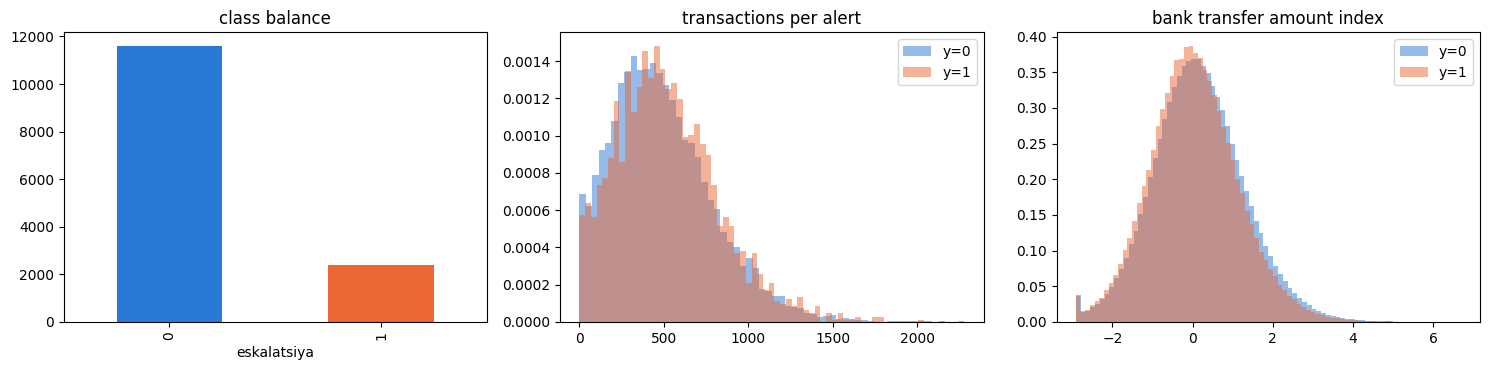

In [4]:
import matplotlib.pyplot as plt
t = tx_train.join(pl.from_pandas(train_sig[["signal_id", "eskalatsiya"]]), on="signal_id")
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
train_sig.eskalatsiya.value_counts().sort_index().plot.bar(ax=ax[0], color=["#2a78d6", "#eb6834"]); ax[0].set_title("class balance")
n = t.group_by(["signal_id", "eskalatsiya"]).len().to_pandas()
for y, c in [(0, "#2a78d6"), (1, "#eb6834")]:
    ax[1].hist(n.loc[n.eskalatsiya == y, "len"], bins=60, alpha=.5, density=True, color=c, label=f"y={y}")
ax[1].set_title("transactions per alert"); ax[1].legend()
b = t.filter(pl.col("tranzaksiya_turi") == "bank_otkazmasi").to_pandas()
for y, c in [(0, "#2a78d6"), (1, "#eb6834")]:
    ax[2].hist(b.loc[b.eskalatsiya == y, "miqdor_indeksi"], bins=80, alpha=.5, density=True, color=c, label=f"y={y}")
ax[2].set_title("bank transfer amount index"); ax[2].legend(); plt.tight_layout(); plt.show()
del t, n, b

## 3. Feature engineering (inlined from `src/signalscope/features`, identical to the pipeline)

In [5]:
# ---- features/aggregates.py ----
"""Base preparation + whole-history aggregate features (volume, amount, direction, type).

All functions take the *prepared* transaction frame from `prepare_tx`, which already contains only
transactions strictly before the signal date (age_days > 0).
"""

import pandas as pd
import polars as pl

TYPES = ["karta", "bank_otkazmasi", "naqd", "xalqaro"]
DIRS = ["kirim", "chiqim"]
QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]


def prepare_tx(tx: pl.DataFrame, signals: pd.DataFrame, baseline: pl.DataFrame | None = None) -> pl.DataFrame:
    """Join signal date, compute age and helper columns, and DROP every transaction at/after the signal date.

    signal_sanasi is date-only, so the alert moment is taken as 00:00:00 of that date; a transaction is
    usable only if tranzaksiya_vaqti < signal_sanasi (age_days > 0).
    """
    s = pl.from_pandas(signals[["signal_id", "signal_sanasi"]]).with_columns(
        pl.col("signal_sanasi").cast(pl.Datetime("us")))
    t = (tx.select("signal_id", "tranzaksiya_vaqti", "kirim_chiqim", "tranzaksiya_turi", "miqdor_indeksi")
         .join(s, on="signal_id", how="inner")
         .with_columns(((pl.col("signal_sanasi") - pl.col("tranzaksiya_vaqti")).dt.total_seconds() / 86400.0)
                       .alias("age_days"))
         .filter(pl.col("age_days") > 0))
    if baseline is not None:
        # de-trend: amount relative to the calendar-week x type median of all TRAIN customers (label-free)
        t = (t.with_columns(pl.col("tranzaksiya_vaqti").dt.truncate("1w").alias("_wk"))
             .join(baseline, on=["_wk", "tranzaksiya_turi"], how="left")
             .with_columns((pl.col("miqdor_indeksi") - pl.col("_base").fill_null(0.0)).alias("miqdor_indeksi"))
             .drop(["_wk", "_base"]))
    t = t.with_columns(
        pl.col("miqdor_indeksi").alias("amt"),
        pl.col("miqdor_indeksi").exp().alias("amt_exp"),
        (pl.col("kirim_chiqim") == "kirim").cast(pl.Int8).alias("is_in"),
        pl.col("age_days").floor().cast(pl.Int32).alias("day"),
        pl.col("tranzaksiya_vaqti").dt.hour().alias("hour"),
        (pl.col("tranzaksiya_vaqti").dt.weekday() - 1).alias("wday"),  # 0 = Monday
    ).with_columns(
        (pl.col("amt_exp") * (2 * pl.col("is_in") - 1)).alias("flow"),
        ((pl.col("hour") < 6)).cast(pl.Int8).alias("is_night"),
        (pl.col("wday") >= 5).cast(pl.Int8).alias("is_weekend"),
    )
    # deterministic order: by signal, time, then remaining columns as tie-breakers
    return t.sort(["signal_id", "tranzaksiya_vaqti", "kirim_chiqim", "tranzaksiya_turi", "amt"])


def _amount_block(col: str, prefix: str, cond: pl.Expr | None = None) -> list[pl.Expr]:
    c = pl.col(col) if cond is None else pl.col(col).filter(cond)
    return [
        c.len().alias(f"{prefix}_n"),
        c.sum().alias(f"{prefix}_sum"),
        c.mean().alias(f"{prefix}_mean"),
        c.std().alias(f"{prefix}_std"),
        c.max().alias(f"{prefix}_max"),
        c.min().alias(f"{prefix}_min"),
        c.median().alias(f"{prefix}_med"),
    ]


def aggregate_features(t: pl.DataFrame, thresholds: dict[str, float]) -> pl.DataFrame:
    """Whole-history aggregates. `thresholds` holds global amount quantiles computed on TRAIN only."""
    a = pl.col("amt")
    e: list[pl.Expr] = [
        pl.len().alias("n_tx"),
        pl.col("day").n_unique().alias("active_days"),
        pl.col("age_days").max().alias("first_age"),
        pl.col("age_days").min().alias("last_age"),
        a.mean().alias("amt_mean"), a.std().alias("amt_std"), a.min().alias("amt_min"), a.max().alias("amt_max"),
        a.skew().alias("amt_skew"), a.kurtosis().alias("amt_kurt"),
        pl.col("amt_exp").sum().alias("amtx_sum"), pl.col("amt_exp").mean().alias("amtx_mean"),
        pl.col("flow").sum().alias("net_flow"),
        (a > thresholds["p90"]).mean().alias("share_gt_p90"),
        (a > thresholds["p99"]).mean().alias("share_gt_p99"),
        (a > thresholds["p99"]).sum().alias("n_gt_p99"),
        (a < thresholds["p10"]).mean().alias("share_lt_p10"),
        pl.col("is_in").mean().alias("in_share"),
    ]
    e += [a.quantile(q, "linear").alias(f"amt_q{int(q * 100)}") for q in QUANTILES]
    for d in DIRS:
        cond = pl.col("kirim_chiqim") == d
        e += _amount_block("amt", f"{d}", cond)
        e.append(pl.col("amt_exp").filter(cond).sum().alias(f"{d}_amtx_sum"))
        e.append(pl.col("amt_exp").filter(cond).max().alias(f"{d}_amtx_max"))
    for ty in TYPES:
        cond = pl.col("tranzaksiya_turi") == ty
        e += _amount_block("amt", f"{ty}", cond)
        e.append(pl.col("amt_exp").filter(cond).sum().alias(f"{ty}_amtx_sum"))
        e.append(cond.mean().alias(f"{ty}_share"))
        e.append(pl.col("day").filter(cond).n_unique().alias(f"{ty}_days"))
        e.append(pl.col("age_days").filter(cond).min().alias(f"{ty}_last_age"))
        for d in DIRS:
            c2 = cond & (pl.col("kirim_chiqim") == d)
            e.append(c2.sum().alias(f"{ty}_{d}_n"))
            e.append(pl.col("amt_exp").filter(c2).sum().alias(f"{ty}_{d}_amtx_sum"))
            e.append(pl.col("amt").filter(c2).mean().alias(f"{ty}_{d}_mean"))
            e.append(pl.col("amt").filter(c2).max().alias(f"{ty}_{d}_max"))
    f = t.group_by("signal_id").agg(e)
    f = f.with_columns(
        (pl.col("first_age") - pl.col("last_age")).alias("span_days"),
        (pl.col("n_tx") / pl.col("active_days")).alias("tx_per_active_day"),
        (pl.col("active_days") / pl.col("first_age").ceil()).alias("active_day_ratio"),
        (pl.col("amt_max") - pl.col("amt_q50")).alias("amt_max_minus_med"),
        (pl.col("kirim_n") / (pl.col("chiqim_n") + 1)).alias("in_out_n_ratio"),
        (pl.col("kirim_amtx_sum") / (pl.col("chiqim_amtx_sum") + 1e-3)).alias("in_out_amtx_ratio"),
        (pl.col("chiqim_amtx_sum") / (pl.col("kirim_amtx_sum") + 1e-3)).alias("out_in_amtx_ratio"),
        (pl.col("kirim_max") - pl.col("chiqim_max")).alias("max_in_minus_max_out"),
        (pl.col("net_flow") / (pl.col("amtx_sum") + 1e-3)).alias("net_flow_norm"),
        (pl.col("naqd_share") + pl.col("xalqaro_share")).alias("cash_intl_share"),
    )
    shares = [pl.col(f"{ty}_share") for ty in TYPES]
    ent = pl.sum_horizontal([pl.when(s > 0).then(-s * s.log()).otherwise(0.0) for s in shares])
    f = f.with_columns(ent.alias("type_entropy"),
                       pl.sum_horizontal([(s > 0).cast(pl.Int8) for s in shares]).alias("type_nunique"))
    return f


def global_thresholds(t_train: pl.DataFrame) -> dict[str, float]:
    """Global amount quantiles from TRAIN transactions (pre-signal), reused unchanged for test."""
    q = t_train.select([pl.col("amt").quantile(p, "linear").alias(k)
                        for k, p in {"p10": 0.1, "p90": 0.9, "p99": 0.99}.items()])
    return {k: float(v) for k, v in q.row(0, named=True).items()}


def type_amount_edges(t_train: pl.DataFrame, n_bins: int = 8) -> dict[str, list[float]]:
    """Per-type amount bin edges (quantiles of TRAIN pre-signal transactions)."""
    qs = [i / n_bins for i in range(1, n_bins)]
    out = {}
    for ty in TYPES:
        a = t_train.filter(pl.col("tranzaksiya_turi") == ty)["amt"]
        out[ty] = [float(a.quantile(q, "linear")) for q in qs]
    return out


def amount_hist_features(t: pl.DataFrame, edges: dict[str, list[float]]) -> pl.DataFrame:
    """Share of each type's transactions falling in each (train-quantile) amount bin, per direction too.

    Captures shifts in the *shape* of the amount distribution (EDA: escalated alerts have relatively more
    small bank transfers and fewer large ones), which mean/max statistics only partly see.
    """
    e: list[pl.Expr] = []
    for ty in TYPES:
        cond = pl.col("tranzaksiya_turi") == ty
        ed = [-1e9] + edges[ty] + [1e9]
        for i in range(len(ed) - 1):
            b = (pl.col("amt") > ed[i]) & (pl.col("amt") <= ed[i + 1])
            e.append((cond & b).sum().alias(f"{ty}_bin{i}_n"))
            for d in DIRS:
                e.append((cond & b & (pl.col("kirim_chiqim") == d)).sum().alias(f"{ty}_{d}_bin{i}_n"))
    f = t.group_by("signal_id").agg(e)
    tot = t.group_by("signal_id").agg([(pl.col("tranzaksiya_turi") == ty).sum().alias(f"_{ty}_tot") for ty in TYPES])
    f = f.join(tot, on="signal_id")
    r = []
    for ty in TYPES:
        for i in range(len(edges[ty]) + 1):
            r.append((pl.col(f"{ty}_bin{i}_n") / pl.col(f"_{ty}_tot")).alias(f"{ty}_bin{i}_frac"))
            for d in DIRS:
                r.append((pl.col(f"{ty}_{d}_bin{i}_n") / pl.col(f"_{ty}_tot")).alias(f"{ty}_{d}_bin{i}_frac"))
    return f.with_columns(r).drop([c for c in f.columns if c.startswith("_")])


def burst_features(tb: pl.DataFrame) -> pl.DataFrame:
    """Aggregates over the pre-signal 'burst' segment (last few minutes before the signal date)."""
    a = pl.col("amt")
    e = [pl.len().alias("b_n"), a.mean().alias("b_amt_mean"), a.std().alias("b_amt_std"), a.max().alias("b_amt_max"),
         a.min().alias("b_amt_min"), a.median().alias("b_amt_med"), pl.col("amt_exp").sum().alias("b_amtx_sum"),
         pl.col("flow").sum().alias("b_net_flow"), pl.col("is_in").mean().alias("b_in_share")]
    for ty in TYPES:
        c = pl.col("tranzaksiya_turi") == ty
        e += [c.sum().alias(f"b_{ty}_n"), a.filter(c).mean().alias(f"b_{ty}_mean"),
              a.filter(c).max().alias(f"b_{ty}_max")]
        for d in DIRS:
            c2 = c & (pl.col("kirim_chiqim") == d)
            e += [c2.sum().alias(f"b_{ty}_{d}_n"), a.filter(c2).mean().alias(f"b_{ty}_{d}_mean")]
    return tb.group_by("signal_id").agg(e)


def burst_relative_features(f: pl.DataFrame) -> pl.DataFrame:
    """Burst segment compared with the customer's own history (needs aggregate + burst + window columns)."""
    r = [
        (pl.col("b_amt_mean") - pl.col("amt_mean")).alias("br_amt_mean_diff"),
        (pl.col("b_amt_max") - pl.col("amt_max")).alias("br_amt_max_diff"),
        ((pl.col("b_amt_mean") - pl.col("amt_mean")) / (pl.col("amt_std") + 1e-3)).alias("br_amt_mean_z"),
        (pl.col("b_n") / (pl.col("n_tx") / pl.col("first_age").ceil() + 1e-3)).alias("br_n_vs_daily_rate"),
        (pl.col("b_n") / (pl.col("n_tx") + 1)).alias("br_n_vs_hist_n"),
        (pl.col("b_in_share") - pl.col("in_share")).alias("br_in_share_diff"),
    ]
    for ty in TYPES:
        r.append((pl.col(f"b_{ty}_n") / (pl.col("b_n") + 1e-9) - pl.col(f"{ty}_share")).alias(f"br_{ty}_share_diff"))
        r.append((pl.col(f"b_{ty}_mean") - pl.col(f"{ty}_mean")).alias(f"br_{ty}_mean_diff"))
    return f.with_columns(r)


def weekly_baseline(tx_train: pl.DataFrame) -> pl.DataFrame:
    """Calendar-week x type median of miqdor_indeksi over all TRAIN transactions (no labels involved)."""
    return (tx_train.with_columns(pl.col("tranzaksiya_vaqti").dt.truncate("1w").alias("_wk"))
            .group_by(["_wk", "tranzaksiya_turi"]).agg(pl.col("miqdor_indeksi").median().alias("_base")))


In [6]:
# ---- features/windows.py ----
"""Recency windows: activity in the last W days before the signal, and its ratio to earlier activity."""

import polars as pl



def window_features(t: pl.DataFrame, windows: list[int]) -> pl.DataFrame:
    age = pl.col("age_days")
    e: list[pl.Expr] = []
    for w in windows:
        cur = age <= w
        prev = (age > w) & (age <= 2 * w)
        e += [
            cur.sum().alias(f"w{w}_n"),
            prev.sum().alias(f"w{w}_prev_n"),
            pl.col("amt_exp").filter(cur).sum().alias(f"w{w}_amtx_sum"),
            pl.col("amt_exp").filter(prev).sum().alias(f"w{w}_prev_amtx_sum"),
            pl.col("amt").filter(cur).mean().alias(f"w{w}_amt_mean"),
            pl.col("amt").filter(cur).max().alias(f"w{w}_amt_max"),
            pl.col("flow").filter(cur).sum().alias(f"w{w}_net_flow"),
            pl.col("is_in").filter(cur).mean().alias(f"w{w}_in_share"),
            (cur & (pl.col("kirim_chiqim") == "chiqim")).sum().alias(f"w{w}_out_n"),
            pl.col("amt_exp").filter(cur & (pl.col("kirim_chiqim") == "chiqim")).sum().alias(f"w{w}_out_amtx_sum"),
            pl.col("day").filter(cur).n_unique().alias(f"w{w}_active_days"),
        ]
        for ty in TYPES:
            e.append((cur & (pl.col("tranzaksiya_turi") == ty)).sum().alias(f"w{w}_{ty}_n"))
    f = t.group_by("signal_id").agg(e)
    # ratios need the whole-history rate: rate = n_tx / observed history length (days)
    base = t.group_by("signal_id").agg(pl.len().alias("_n"), pl.col("age_days").max().ceil().alias("_hist"),
                                       pl.col("amt_exp").sum().alias("_ax"))
    f = f.join(base, on="signal_id")
    r = []
    for w in windows:
        r += [
            (pl.col(f"w{w}_n") / (pl.col(f"w{w}_prev_n") + 1)).alias(f"w{w}_vs_prev_n"),
            (pl.col(f"w{w}_amtx_sum") / (pl.col(f"w{w}_prev_amtx_sum") + 1)).alias(f"w{w}_vs_prev_amtx"),
            ((pl.col(f"w{w}_n") / w) / (pl.col("_n") / pl.col("_hist"))).alias(f"w{w}_rate_vs_hist"),
            ((pl.col(f"w{w}_amtx_sum") / w) / (pl.col("_ax") / pl.col("_hist"))).alias(f"w{w}_amtx_rate_vs_hist"),
            (pl.col(f"w{w}_n") / pl.col("_n")).alias(f"w{w}_share_n"),
            (pl.col(f"w{w}_out_n") / (pl.col(f"w{w}_n") + 1)).alias(f"w{w}_out_frac"),
        ]
        for ty in ("naqd", "xalqaro"):
            r.append((pl.col(f"w{w}_{ty}_n") / (pl.col(f"w{w}_n") + 1)).alias(f"w{w}_{ty}_frac"))
    # acceleration: short-window rate relative to the next longer window
    for a, b in zip(windows[:-1], windows[1:]):
        r.append(((pl.col(f"w{a}_n") / a) / (pl.col(f"w{b}_n") / b + 1e-3)).alias(f"accel_{a}_{b}"))
    return f.with_columns(r).drop(["_n", "_hist", "_ax"])


def shift_features(t: pl.DataFrame, windows: tuple[int, ...] = (7, 14, 30, 60)) -> pl.DataFrame:
    """Behaviour change: amount level / direction / type mix in the last W days minus the level before W."""
    age = pl.col("age_days")
    e: list[pl.Expr] = []
    for w in windows:
        cur, old = age <= w, age > w
        e += [(pl.col("amt").filter(cur).mean() - pl.col("amt").filter(old).mean()).alias(f"sh{w}_amt_mean"),
              (pl.col("amt").filter(cur).std() - pl.col("amt").filter(old).std()).alias(f"sh{w}_amt_std"),
              (pl.col("is_in").filter(cur).mean() - pl.col("is_in").filter(old).mean()).alias(f"sh{w}_in_share")]
        for ty in ("karta", "bank_otkazmasi", "naqd"):
            c = pl.col("tranzaksiya_turi") == ty
            e.append((pl.col("amt").filter(cur & c).mean() - pl.col("amt").filter(old & c).mean())
                     .alias(f"sh{w}_{ty}_amt_mean"))
            e.append((c.filter(cur).mean() - c.filter(old).mean()).alias(f"sh{w}_{ty}_share"))
    return t.group_by("signal_id").agg(e)


In [7]:
# ---- features/temporal.py ----
"""Time-of-day / weekday patterns, inter-arrival gaps, daily burstiness and trends."""

import polars as pl

HOUR_BINS = [(0, 6), (6, 9), (9, 12), (12, 15), (15, 18), (18, 21), (21, 24)]


def temporal_features(t: pl.DataFrame, trend_windows: tuple[int, ...] = (30, 60, 90, 180)) -> pl.DataFrame:
    h = pl.col("hour")
    e: list[pl.Expr] = [
        pl.col("is_night").mean().alias("night_share"),
        pl.col("is_weekend").mean().alias("weekend_share"),
        h.mean().alias("hour_mean"), h.std().alias("hour_std"),
        pl.col("amt_exp").filter(pl.col("is_night") == 1).sum().alias("night_amtx_sum"),
        ((pl.col("is_night") == 1) & (pl.col("kirim_chiqim") == "chiqim")).sum().alias("night_out_n"),
        pl.col("tranzaksiya_vaqti").dt.minute().eq(0).mean().alias("round_minute_share"),
    ]
    e += [((h >= a) & (h < b)).mean().alias(f"hour_{a}_{b}_share") for a, b in HOUR_BINS]
    e += [(pl.col("wday") == d).mean().alias(f"wday{d}_share") for d in range(7)]
    # exponentially weighted activity (recency-weighted counts / amounts)
    for hl in (3, 7, 30):
        wgt = (-pl.col("age_days") * (0.6931471805599453 / hl)).exp()
        e.append(wgt.sum().alias(f"ewm{hl}_n"))
        e.append((wgt * pl.col("amt_exp")).sum().alias(f"ewm{hl}_amtx"))
        e.append((wgt * pl.col("flow")).sum().alias(f"ewm{hl}_flow"))
    # linear trend of daily count / amount over the last W days (zeros included), via closed-form sums.
    # x = day index counted towards the signal (x = W-1-day), so positive slope = activity increasing.
    for w in trend_windows:
        cur = pl.col("day") < w
        x = (w - 1 - pl.col("day")).cast(pl.Float64)
        xm, xv = (w - 1) / 2.0, (w * w - 1) / 12.0
        e.append((((x.filter(cur).sum() / w) - xm * (cur.sum() / w)) / xv).alias(f"trend{w}_n"))
        e.append((((x * pl.col("amt_exp")).filter(cur).sum() / w
                   - xm * (pl.col("amt_exp").filter(cur).sum() / w)) / xv).alias(f"trend{w}_amtx"))
    f = t.group_by("signal_id").agg(e)

    # inter-arrival gaps (hours) within each signal's history
    g = (t.select("signal_id", "tranzaksiya_vaqti", "is_in", "amt")
         .with_columns((pl.col("tranzaksiya_vaqti").diff().over("signal_id").dt.total_seconds() / 3600.0)
                       .alias("gap_h")))
    gap = pl.col("gap_h").drop_nulls()
    gf = g.group_by("signal_id").agg(
        gap.mean().alias("gap_mean"), gap.std().alias("gap_std"), gap.median().alias("gap_med"),
        gap.min().alias("gap_min"), gap.max().alias("gap_max"),
        gap.quantile(0.1, "linear").alias("gap_q10"), gap.quantile(0.9, "linear").alias("gap_q90"),
        (gap < 1).mean().alias("gap_lt1h_share"), (gap < (1 / 12)).mean().alias("gap_lt5m_share"),
        (gap > 24 * 7).sum().alias("gap_gt7d_n"),
        gap.log1p().mean().alias("gap_logmean"), gap.log1p().std().alias("gap_logstd"),
    ).with_columns((pl.col("gap_std") / pl.col("gap_mean")).alias("gap_cv"))
    # dormancy then reactivation: longest gap and how recently the activity resumed after it
    g2 = g.with_columns(pl.col("gap_h").fill_null(0).alias("gap_h"))
    idx = (g2.group_by("signal_id")
           .agg(pl.col("gap_h").max().alias("_mg"),
                pl.col("tranzaksiya_vaqti").sort_by("gap_h").last().alias("_resume_ts"),
                pl.col("tranzaksiya_vaqti").max().alias("_last_ts")))
    gf = gf.join(idx, on="signal_id").with_columns(
        ((pl.col("_last_ts") - pl.col("_resume_ts")).dt.total_seconds() / 86400.0).alias("days_active_after_max_gap"),
        ((pl.col("_mg") > 24 * 30)).cast(pl.Int8).alias("dormant_reactivated_30d"),
    ).drop(["_mg", "_resume_ts", "_last_ts"])

    # daily count distribution with zero-days included (history = observed span in whole days)
    d = t.group_by(["signal_id", "day"]).agg(pl.len().alias("c"), pl.col("amt_exp").sum().alias("ax"))
    hist = t.group_by("signal_id").agg(pl.col("day").max().add(1).alias("H"))
    dd = (d.join(hist, on="signal_id").group_by("signal_id")
          .agg(pl.col("c").sum().alias("_s"), (pl.col("c") ** 2).sum().alias("_s2"),
               pl.col("c").max().alias("daily_n_max"), pl.col("ax").max().alias("daily_amtx_max"),
               pl.col("ax").sum().alias("_ax"), pl.col("H").first().alias("_H"),
               pl.col("day").sort_by("c").last().alias("busiest_day_age"))
          .with_columns((pl.col("_s") / pl.col("_H")).alias("daily_n_mean"))
          .with_columns(((pl.col("_s2") / pl.col("_H")) - pl.col("daily_n_mean") ** 2).clip(0).sqrt()
                        .alias("daily_n_std"))
          .with_columns(((pl.col("daily_n_max") - pl.col("daily_n_mean")) / (pl.col("daily_n_std") + 1e-6))
                        .alias("burst_z"),
                        (pl.col("daily_amtx_max") / (pl.col("_ax") / pl.col("_H") + 1e-6)).alias("burst_amtx_ratio"))
          .drop(["_s", "_s2", "_ax", "_H"]))
    return f.join(gf, on="signal_id", how="left").join(dd, on="signal_id", how="left")


In [8]:
# ---- features/sequence.py ----
"""Order-aware features: pass-through (money in, then quickly out) and the last-k transactions flattened."""

import polars as pl

TYPE_CODE = {"karta": 0, "bank_otkazmasi": 1, "naqd": 2, "xalqaro": 3}


def passthrough_features(t: pl.DataFrame) -> pl.DataFrame:
    """For every outgoing tx, look back at the most recent incoming tx of the same signal (as-of join)."""
    cols = ["signal_id", "tranzaksiya_vaqti", "amt", "amt_exp", "tranzaksiya_turi"]
    outs = t.filter(pl.col("is_in") == 0).select(cols).sort("tranzaksiya_vaqti")
    ins = (t.filter(pl.col("is_in") == 1).select(cols)
           .rename({"tranzaksiya_vaqti": "in_ts", "amt": "in_amt", "amt_exp": "in_amtx", "tranzaksiya_turi": "in_type"})
           .with_columns(pl.col("in_ts").alias("_k")).sort("_k"))
    j = outs.with_columns(pl.col("tranzaksiya_vaqti").alias("_k")).join_asof(
        ins, on="_k", by="signal_id", strategy="backward")
    j = j.with_columns(((pl.col("tranzaksiya_vaqti") - pl.col("in_ts")).dt.total_seconds() / 3600.0).alias("lag_h"),
                       (pl.col("amt") - pl.col("in_amt")).abs().alias("amt_diff"))
    lag = pl.col("lag_h")
    e = [
        pl.len().alias("pt_out_n"),
        lag.median().alias("pt_lag_med"), lag.mean().alias("pt_lag_mean"), lag.min().alias("pt_lag_min"),
        (lag < 1).sum().alias("pt_1h_n"), (lag < 24).sum().alias("pt_24h_n"),
        ((lag < 24) & (pl.col("amt_diff") < 0.25)).sum().alias("pt_24h_similar_n"),
        ((lag < 72) & (pl.col("amt_diff") < 0.25)).sum().alias("pt_72h_similar_n"),
        ((lag < 24) & (pl.col("amt") > 1.0)).sum().alias("pt_24h_large_n"),
        pl.col("amt_diff").filter(lag < 24).mean().alias("pt_24h_amtdiff_mean"),
        (pl.col("amt_exp").filter(lag < 24).sum()).alias("pt_24h_out_amtx"),
        ((lag < 24) & (pl.col("in_type") == "xalqaro")).sum().alias("pt_24h_from_intl_n"),
        ((lag < 24) & (pl.col("tranzaksiya_turi").is_in(["naqd", "xalqaro"]))).sum().alias("pt_24h_to_cash_intl_n"),
    ]
    f = j.group_by("signal_id").agg(e).with_columns(
        (pl.col("pt_24h_n") / pl.col("pt_out_n")).alias("pt_24h_frac"),
        (pl.col("pt_24h_similar_n") / pl.col("pt_out_n")).alias("pt_24h_similar_frac"),
    )
    return f


def last_k_features(t: pl.DataFrame, k: int) -> pl.DataFrame:
    """Last k transactions before the signal, flattened (rank 0 = most recent)."""
    r = (t.select("signal_id", "tranzaksiya_vaqti", "age_days", "amt", "is_in", "tranzaksiya_turi")
         .with_columns(pl.col("tranzaksiya_vaqti").rank("ordinal", descending=True).over("signal_id")
                       .sub(1).alias("rk"))
         .filter(pl.col("rk") < k)
         .with_columns(pl.col("tranzaksiya_turi").replace_strict(TYPE_CODE, return_dtype=pl.Int8).alias("ty")))
    wide = None
    for c, name in [("amt", "amt"), ("age_days", "age"), ("is_in", "in"), ("ty", "type")]:
        p = r.pivot(on="rk", index="signal_id", values=c, aggregate_function="first", sort_columns=True)
        p = p.rename({str(i): f"last{i}_{name}" for i in range(k) if str(i) in p.columns})
        wide = p if wide is None else wide.join(p, on="signal_id", how="left")
    # make the column set independent of data (k columns per block even if nobody has k tx)
    missing = [f"last{i}_{n}" for n in ("amt", "age", "in", "type") for i in range(k)
               if f"last{i}_{n}" not in wide.columns]
    if missing:
        wide = wide.with_columns([pl.lit(None, dtype=pl.Float64).alias(m) for m in missing])
    ordered = ["signal_id"] + [f"last{i}_{n}" for n in ("amt", "age", "in", "type") for i in range(k)]
    lastk = r.group_by("signal_id").agg(pl.col("amt").mean().alias(f"last{k}_amt_mean"),
                                        pl.col("amt").max().alias(f"last{k}_amt_max"),
                                        pl.col("is_in").mean().alias(f"last{k}_in_share"),
                                        pl.col("age_days").max().alias(f"last{k}_span_days"),
                                        (pl.col("ty") >= 2).mean().alias(f"last{k}_cash_intl_share"))
    return wide.select(ordered).cast({c: pl.Float64 for c in ordered[1:]}).join(lastk, on="signal_id", how="left")


def transition_features(t: pl.DataFrame) -> pl.DataFrame:
    """Order-aware features suggested by AmEx/AML write-ups: direction/type transitions, consecutive amount deltas,
    last-vs-history contrasts and short-horizon velocity (max transactions in rolling 5m/1h/6h/24h)."""
    s = t.select("signal_id", "tranzaksiya_vaqti", "amt", "is_in", "tranzaksiya_turi").with_columns(
        pl.col("is_in").shift(1).over("signal_id").alias("p_in"),
        pl.col("tranzaksiya_turi").shift(1).over("signal_id").alias("p_ty"),
        pl.col("amt").diff().over("signal_id").alias("d_amt"),
        pl.col("amt").rank("average").over("signal_id").alias("amt_rank"),
        pl.len().over("signal_id").alias("_n"),
    )
    e: list[pl.Expr] = [
        (pl.col("is_in") != pl.col("p_in")).mean().alias("tr_dir_switch_rate"),
        (pl.col("tranzaksiya_turi") != pl.col("p_ty")).mean().alias("tr_type_switch_rate"),
        ((pl.col("p_in") == 1) & (pl.col("is_in") == 0)).mean().alias("tr_in_to_out_rate"),
        ((pl.col("p_in") == 0) & (pl.col("is_in") == 1)).mean().alias("tr_out_to_in_rate"),
        pl.col("d_amt").abs().mean().alias("tr_damt_abs_mean"), pl.col("d_amt").std().alias("tr_damt_std"),
        (pl.col("d_amt").abs() < 0.05).mean().alias("tr_damt_similar_share"),
        pl.col("amt").last().alias("tr_last_amt"),
        (pl.col("amt").last() - pl.col("amt").mean()).alias("tr_last_minus_mean"),
        ((pl.col("amt").last() - pl.col("amt").mean()) / (pl.col("amt").std() + 1e-3)).alias("tr_last_z"),
        (pl.col("amt").tail(5).mean() - pl.col("amt").mean()).alias("tr_last5_minus_mean"),
        (pl.col("amt").tail(20).mean() - pl.col("amt").mean()).alias("tr_last20_minus_mean"),
        (pl.col("amt_rank").last() / pl.col("_n").last()).alias("tr_last_amt_pct_rank"),
        (pl.col("amt").first() - pl.col("amt").last()).alias("tr_first_minus_last"),
    ]
    types = ["karta", "bank_otkazmasi", "naqd", "xalqaro"]
    for a in types:
        for b in types:
            if a != b:
                e.append(((pl.col("p_ty") == a) & (pl.col("tranzaksiya_turi") == b)).mean().alias(f"tr_{a}_to_{b}"))
    f = s.group_by("signal_id").agg(e)
    # velocity: max number of transactions inside any rolling window of length h (per signal)
    ts = t.select("signal_id", "tranzaksiya_vaqti").with_columns(pl.lit(1).alias("one"))
    for name, per in [("5m", "5m"), ("1h", "1h"), ("6h", "6h"), ("24h", "24h")]:
        r = (ts.rolling(index_column="tranzaksiya_vaqti", period=per, group_by="signal_id")
             .agg(pl.col("one").sum().alias("c")).group_by("signal_id").agg(pl.col("c").max().alias(f"vel_max_{name}")))
        f = f.join(r, on="signal_id", how="left")
    return f


In [9]:
# ---- features/__init__.py ----
"""Feature builder: one row per signal_id, computed only from transactions strictly before signal_sanasi."""

import pandas as pd
import polars as pl


__all__ = ["build_features", "prepare_tx", "fit_reference", "split_burst"]


def split_burst(t: pl.DataFrame, burst_seconds: float) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Split prepared tx into (history, burst). Burst = the last `burst_seconds` before the signal date.

    EDA: ~40 transactions per alert are stamped 23:57-23:59 the evening before the signal date (a timestamp
    artefact of the synthetic generator); they are kept (they are pre-signal) but summarised separately so they
    do not distort history statistics.
    """
    is_b = pl.col("age_days") * 86400.0 <= burst_seconds
    return t.filter(~is_b), t.filter(is_b)


def fit_reference(signals_train: pd.DataFrame, tx_train: pl.DataFrame, burst_seconds: float,
                  detrend: bool = False) -> dict:
    """Global reference statistics fitted on TRAIN transactions only (reused as-is for test)."""
    base = weekly_baseline(tx_train) if detrend else None
    t, _ = split_burst(prepare_tx(tx_train, signals_train, base), burst_seconds)
    return {"thresholds": global_thresholds(t), "edges": type_amount_edges(t), "baseline": base}


def build_features(signals: pd.DataFrame, tx: pl.DataFrame, ref: dict, windows: list[int], last_k: int,
                   burst_seconds: float = 300.0, calendar: bool = False, families: tuple[str, ...] | None = None
                   ) -> pd.DataFrame:
    """Build the model matrix. Same code path for train and test; output row order = `signals` order.

    `ref` must come from `fit_reference` on TRAIN so test never influences features.
    The returned frame has `signal_id` plus float feature columns only (signal_id is NOT a feature).
    """
    fam = families or ("agg", "win", "time", "pt", "lastk", "hist", "burst", "shift")
    t_all = prepare_tx(tx, signals, ref.get("baseline"))
    t, tb = split_burst(t_all, burst_seconds)
    parts = []
    if "agg" in fam:
        parts.append(aggregate_features(t, ref["thresholds"]))
    if "win" in fam:
        parts.append(window_features(t, windows))
    if "trans" in fam:
        parts.append(transition_features(t))
    if "shift" in fam:
        parts.append(shift_features(t))
    if "trans" in fam:
        parts.append(transition_features(t))
    if "shift" in fam:
        parts.append(shift_features(t))
    if "time" in fam:
        parts.append(temporal_features(t))
    if "pt" in fam:
        parts.append(passthrough_features(t))
    if "lastk" in fam:
        parts.append(last_k_features(t, last_k))
    if "hist" in fam:
        parts.append(amount_hist_features(t, ref["edges"]))
    if "burst" in fam:
        parts.append(burst_features(tb))
    f = pl.from_pandas(signals[["signal_id"]])
    for p in parts:
        f = f.join(p, on="signal_id", how="left")
    if "agg" in fam and "burst" in fam:
        f = burst_relative_features(f)
    if calendar:
        sd = pl.from_pandas(signals[["signal_id", "signal_sanasi"]])
        f = f.join(sd.select("signal_id", pl.col("signal_sanasi").dt.month().alias("sig_month"),
                             pl.col("signal_sanasi").dt.weekday().alias("sig_wday"),
                             pl.col("signal_sanasi").dt.day().alias("sig_mday"),
                             ((pl.col("signal_sanasi") - pl.datetime(2025, 1, 1)).dt.total_days()).alias("sig_days")),
                   on="signal_id", how="left")
    df = f.to_pandas()
    num = [c for c in df.columns if c != "signal_id"]
    df[num] = df[num].astype("float64")
    # signals with no transactions in a segment: counts are 0, statistics stay NaN (GBDT handles NaN)
    cnt = [c for c in num if c.endswith("_n") or c in ("n_tx", "active_days")]
    df[cnt] = df[cnt].fillna(0.0)
    return df.reset_index(drop=True)


In [10]:
FAMILIES = ('agg', 'win', 'lastk', 'hist', 'burst')
WINDOWS, LAST_K, BURST_S = [1, 3, 7, 14, 30, 60, 90], 20, 300
t0 = time.time()
ref = fit_reference(train_sig, tx_train, BURST_S)                       # train-only reference statistics
kw = dict(ref=ref, windows=WINDOWS, last_k=LAST_K, burst_seconds=BURST_S, calendar=False, families=FAMILIES)
F_train = build_features(train_sig, tx_train, **kw)
F_test = build_features(test_sig, tx_test, **kw)
assert list(F_train.columns) == list(F_test.columns)
X, X_test = F_train.drop(columns="signal_id"), F_test.drop(columns="signal_id")   # signal_id is NOT a feature
y = train_sig["eskalatsiya"].to_numpy()
print("features", X.shape, X_test.shape, f"{time.time() - t0:.1f}s")

features (14000, 626) (6000, 626) 5.4s


## 4. Validation scheme and models (inlined `cv.py`, `models.py`, `ensemble.py`)

In [11]:
# ---- cv.py ----
"""Single CV entry point used by every model: repeated stratified K-fold + OOF bookkeeping.

Split choice (see docs/DECISIONS.md): train and test cover the same date range and adversarial validation AUC
is ~0.50, so the test set is a random sample of the same distribution -> RepeatedStratifiedKFold.
"""

from dataclasses import dataclass, field
from typing import Callable

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold

# fit_predict(X_tr, y_tr, X_va, y_va, X_te, seed) -> (pred_va, pred_te, info)
FitPredict = Callable[[pd.DataFrame, np.ndarray, pd.DataFrame, np.ndarray, pd.DataFrame | None, int],
                      tuple[np.ndarray, np.ndarray | None, dict]]


@dataclass
class CVResult:
    oof: np.ndarray                       # mean OOF prediction over repeats
    test: np.ndarray | None               # mean test prediction over all fold models
    fold_auc: list[float]
    repeat_oof_auc: list[float]
    infos: list[dict] = field(default_factory=list)

    @property
    def oof_auc(self) -> float:
        return float(np.mean(self.repeat_oof_auc))

    def summary(self) -> dict:
        return {"fold_auc_mean": round(float(np.mean(self.fold_auc)), 5),
                "fold_auc_std": round(float(np.std(self.fold_auc)), 5),
                "oof_auc_mean_over_repeats": round(self.oof_auc, 5),
                "oof_auc_of_mean_pred": None,
                "n_folds": len(self.fold_auc)}


def splits(y: np.ndarray, n_splits: int, n_repeats: int, seed: int) -> list[tuple[np.ndarray, np.ndarray]]:
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    return list(rskf.split(np.zeros(len(y)), y))


def run_cv(X: pd.DataFrame, y: np.ndarray, fit_predict: FitPredict, n_splits: int = 5, n_repeats: int = 3,
           seed: int = 42, X_test: pd.DataFrame | None = None, verbose: bool = False) -> CVResult:
    """Run repeated stratified CV. Any preprocessing must live inside `fit_predict` (fit on train fold only)."""
    n = len(y)
    oof_sum, oof_cnt = np.zeros(n), np.zeros(n)
    test_sum = None if X_test is None else np.zeros(len(X_test))
    fold_auc, rep_auc, infos = [], [], []
    rep_oof = np.zeros(n)
    for i, (tr, va) in enumerate(splits(y, n_splits, n_repeats, seed)):
        p_va, p_te, info = fit_predict(X.iloc[tr], y[tr], X.iloc[va], y[va], X_test, seed + i)
        rep_oof[va] = p_va
        oof_sum[va] += p_va
        oof_cnt[va] += 1
        fold_auc.append(float(roc_auc_score(y[va], p_va)))
        infos.append(info)
        if p_te is not None and test_sum is not None:
            test_sum += p_te
        if verbose:
            print(f"fold {i}: auc={fold_auc[-1]:.5f} {info}")
        if (i + 1) % n_splits == 0:
            rep_auc.append(float(roc_auc_score(y, rep_oof)))
            rep_oof = np.zeros(n)
    k = len(fold_auc)
    return CVResult(oof=oof_sum / np.maximum(oof_cnt, 1),
                    test=None if test_sum is None else test_sum / k,
                    fold_auc=fold_auc, repeat_oof_auc=rep_auc, infos=infos)


In [12]:
# ---- models.py ----
"""Model factories. Each returns a `fit_predict` closure compatible with `cv.run_cv`.

Early stopping never looks at the validation fold: when `inner_es` is set, 10% of the *training* fold is held
out for early stopping; otherwise a fixed number of boosting rounds (from config) is used.
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


def _inner(X, y, seed, frac=0.1):
    return train_test_split(X, y, test_size=frac, stratify=y, random_state=seed)


def lgbm(params: dict, n_jobs: int, inner_es: bool = False, es_rounds: int = 200):
    import lightgbm as lgb

    def fp(X_tr, y_tr, X_va, y_va, X_te, seed):
        p = {"objective": "binary", "verbose": -1, "n_jobs": n_jobs, "deterministic": True,
             "force_col_wise": True, "random_state": seed, **params}
        m = lgb.LGBMClassifier(**p)
        info = {}
        if inner_es:
            a, b, ya, yb = _inner(X_tr, y_tr, seed)
            m.fit(a, ya, eval_set=[(b, yb)], eval_metric="auc",
                  callbacks=[lgb.early_stopping(es_rounds, verbose=False)])
            info["best_iter"] = int(m.best_iteration_)
        else:
            m.fit(X_tr, y_tr)
        pv = m.predict_proba(X_va)[:, 1]
        pt = None if X_te is None else m.predict_proba(X_te)[:, 1]
        info["gain"] = m.booster_.feature_importance("gain")
        return pv, pt, info
    return fp


def xgb(params: dict, n_jobs: int, device: str = "cpu", inner_es: bool = False, es_rounds: int = 200):
    import xgboost as xg

    def fp(X_tr, y_tr, X_va, y_va, X_te, seed):
        p = {"objective": "binary:logistic", "eval_metric": "auc", "tree_method": "hist", "device": device,
             "n_jobs": n_jobs, "random_state": seed, **params}
        info = {}
        if inner_es:
            p["early_stopping_rounds"] = es_rounds
            m = xg.XGBClassifier(**p)
            a, b, ya, yb = _inner(X_tr, y_tr, seed)
            m.fit(a, ya, eval_set=[(b, yb)], verbose=False)
            info["best_iter"] = int(m.best_iteration)
        else:
            m = xg.XGBClassifier(**p)
            m.fit(X_tr, y_tr, verbose=False)
        pv = m.predict_proba(X_va)[:, 1]
        pt = None if X_te is None else m.predict_proba(X_te)[:, 1]
        return pv, pt, info
    return fp


def catboost(params: dict, n_jobs: int, device: str = "CPU", inner_es: bool = False, es_rounds: int = 300):
    from catboost import CatBoostClassifier

    def fp(X_tr, y_tr, X_va, y_va, X_te, seed):
        p = {"loss_function": "Logloss", "eval_metric": "AUC", "random_seed": seed, "verbose": 0,
             "thread_count": n_jobs, "task_type": device, "allow_writing_files": False, **params}
        info = {}
        m = CatBoostClassifier(**p)
        if inner_es:
            a, b, ya, yb = _inner(X_tr, y_tr, seed)
            m.fit(a, ya, eval_set=(b, yb), early_stopping_rounds=es_rounds, use_best_model=True)
            info["best_iter"] = int(m.get_best_iteration())
        else:
            m.fit(X_tr, y_tr)
        pv = m.predict_proba(X_va)[:, 1]
        pt = None if X_te is None else m.predict_proba(X_te)[:, 1]
        return pv, pt, info
    return fp


def logreg(C: float = 0.05):
    """Median impute + quantile-normal scaling + L2 logistic regression; all fitted on the train fold only."""
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import QuantileTransformer

    def fp(X_tr, y_tr, X_va, y_va, X_te, seed):
        pipe = make_pipeline(SimpleImputer(strategy="median"),
                             QuantileTransformer(n_quantiles=200, output_distribution="normal", random_state=seed),
                             LogisticRegression(C=C, max_iter=3000))
        keep = X_tr.columns[X_tr.notna().any()]
        pipe.fit(X_tr[keep], y_tr)
        pv = pipe.predict_proba(X_va[keep])[:, 1]
        pt = None if X_te is None else pipe.predict_proba(X_te[keep])[:, 1]
        return pv, pt, {}
    return fp


def feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """Drop the id column; everything else is a numeric feature."""
    return df.drop(columns=[c for c in ("signal_id",) if c in df.columns])


def rank01(x: np.ndarray) -> np.ndarray:
    """Monotone map to (0,1) without ties created: average rank / (n+1)."""
    from scipy.stats import rankdata
    return rankdata(x, method="average") / (len(x) + 1)


In [13]:
# ---- ensemble.py ----
"""Rank blending with non-negative simplex weights fitted on OOF predictions, plus a fold-wise overfit check."""

import numpy as np
from scipy.optimize import minimize
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score


def to_ranks(preds: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    return {k: rankdata(v) / len(v) for k, v in preds.items()}


def blend(ranks: dict[str, np.ndarray], w: dict[str, float]) -> np.ndarray:
    return sum(w[k] * ranks[k] for k in w)


def fit_weights(ranks: dict[str, np.ndarray], y: np.ndarray, l2: float = 0.01) -> dict[str, float]:
    """Maximise AUC of the rank blend over the simplex (softmax parametrisation, Nelder-Mead), with a small
    L2 pull towards equal weights to avoid overfitting the OOF set."""
    keys = sorted(ranks)
    k = len(keys)
    if k == 1:
        return {keys[0]: 1.0}
    M = np.column_stack([ranks[c] for c in keys])

    def weights(z):
        e = np.exp(z - z.max())
        return e / e.sum()

    def loss(z):
        w = weights(z)
        return -roc_auc_score(y, M @ w) + l2 * np.sum((w - 1 / k) ** 2)

    best = None
    for start in [np.zeros(k)] + [np.eye(k)[i] * 2 for i in range(k)]:
        r = minimize(loss, start, method="Nelder-Mead", options={"maxiter": 2000, "xatol": 1e-4, "fatol": 1e-7})
        if best is None or r.fun < best.fun:
            best = r
    w = weights(best.x)
    return {c: float(round(v, 4)) for c, v in zip(keys, w)}


def foldwise_check(ranks: dict[str, np.ndarray], y: np.ndarray, folds: list[tuple[np.ndarray, np.ndarray]]
                   ) -> dict:
    """Fit weights on K-1 folds of OOF, score the held-out fold; compare with equal weights and best single."""
    rows = []
    for tr, va in folds:
        w = fit_weights({k: v[tr] for k, v in ranks.items()}, y[tr])
        eq = {k: 1 / len(ranks) for k in ranks}
        rows.append({"fitted": roc_auc_score(y[va], blend({k: v[va] for k, v in ranks.items()}, w)),
                     "equal": roc_auc_score(y[va], blend({k: v[va] for k, v in ranks.items()}, eq)),
                     **{f"single_{k}": roc_auc_score(y[va], v[va]) for k, v in ranks.items()}})
    keys = rows[0].keys()
    return {k: round(float(np.mean([r[k] for r in rows])), 5) for k in keys}


In [14]:
TUNED = {
 "lgb": {
  "colsample_bytree": 0.17585404526174037,
  "learning_rate": 0.014013613634020712,
  "max_depth": 5,
  "min_child_samples": 157,
  "n_estimators": 724,
  "num_leaves": 5,
  "reg_alpha": 0.004547905376941999,
  "reg_lambda": 21.441913393241975,
  "scale_pos_weight": 1.0,
  "subsample": 0.6740177830108962,
  "subsample_freq": 1
 },
 "xgb": {
  "colsample_bynode": 0.5338907528909055,
  "colsample_bytree": 0.17874934464757225,
  "gamma": 0.0003187124194807891,
  "learning_rate": 0.008942030320974462,
  "max_depth": 3,
  "min_child_weight": 63.54362099848529,
  "n_estimators": 802,
  "reg_alpha": 0.0016033916781709738,
  "reg_lambda": 0.10735891802886201,
  "scale_pos_weight": 1.0,
  "subsample": 0.7449762061168369
 },
 "cat": {
  "bagging_temperature": 0.9009065048647944,
  "border_count": 128,
  "depth": 4,
  "iterations": 209,
  "l2_leaf_reg": 50.05069385076161,
  "learning_rate": 0.06900965861283849,
  "random_strength": 0.30867472356706827,
  "rsm": 0.05984035344031522
 }
}   # frozen Optuna results (configs/tuned/*.yaml)
REFIT_FACTOR = 1.1
FINAL_SEEDS = [42, 7, 2024, 31337, 1234]
FINAL_MODELS = ['lgb']           # chosen by the fold-wise blend check in the pipeline
FINAL_WEIGHTS = {'lgb': 1.0}

def factory(kind, scale=1.0):
    p = dict(TUNED.get(kind, {}))
    if kind in ("lgb", "xgb"): p["n_estimators"] = int(p["n_estimators"] * scale)
    if kind == "cat": p["iterations"] = int(p["iterations"] * scale)
    return {"lgb": lambda: lgbm(p, N_JOBS), "xgb": lambda: xgb(p, N_JOBS, device="cpu"),
            "cat": lambda: catboost(p, N_JOBS, device="CPU"), "lr": lambda: logreg()}[kind]()

In [15]:
# Repeated stratified K-fold: train/test cover the same dates and adversarial AUC ~0.5 -> random split is valid.
cv_models = ["lgb"] if FAST_MODE else ["lgb", "xgb", "cat", "lr"]
repeats = 1 if FAST_MODE else 3
cv_res = {}
for k in cv_models:
    t0 = time.time()
    r = run_cv(X, y, factory(k), 5, repeats, SEED)
    cv_res[k] = r
    print(f"{k:4s} fold AUC {np.mean(r.fold_auc):.4f} ± {np.std(r.fold_auc):.4f} | OOF AUC {roc_auc_score(y, r.oof):.4f} | {time.time() - t0:.0f}s")
if len(cv_res) > 1:
    ranks = to_ranks({k: v.oof for k, v in cv_res.items()})
    print("fold-wise blend check:", foldwise_check(ranks, y, splits(y, 5, 1, SEED + 100)))
# pipeline reference numbers (artifacts/cv_report.json) for comparison:
print("pipeline:", {"lgb": 0.64996, "xgb": 0.64952, "cat": 0.64599, "lr": 0.61695})

lgb  fold AUC 0.6479 ± 0.0125 | OOF AUC 0.6500 | 15s


xgb  fold AUC 0.6477 ± 0.0123 | OOF AUC 0.6495 | 101s


cat  fold AUC 0.6409 ± 0.0114 | OOF AUC 0.6460 | 19s


lr   fold AUC 0.6128 ± 0.0126 | OOF AUC 0.6169 | 74s


fold-wise blend check: {'fitted': 0.64987, 'equal': 0.64943, 'single_lgb': 0.65002, 'single_xgb': 0.64948, 'single_cat': 0.64597, 'single_lr': 0.61718}
pipeline: {'lgb': 0.64996, 'xgb': 0.64952, 'cat': 0.64599, 'lr': 0.61695}


## 5. Final fit on all training data, prediction, submission file

In [16]:
from scipy.stats import rankdata
seeds = FINAL_SEEDS[:1] if FAST_MODE else FINAL_SEEDS
models_used = ["lgb"] if FAST_MODE else FINAL_MODELS
score = np.zeros(len(X_test)); oof_blend = np.zeros(len(X))
for k in models_used:
    preds = []
    for sd in seeds:
        _, pt, _ = factory(k, REFIT_FACTOR)(X, y, X.iloc[:10], y[:10], X_test, sd)
        preds.append(pt)
        if k == "lr": break
    w = FINAL_WEIGHTS.get(k, 1.0) if not FAST_MODE else 1.0
    score += w * rankdata(np.mean(preds, axis=0)) / len(X_test)
    oof_blend += w * rankdata(cv_res[k].oof) / len(X)
final = rankdata(score, method="average") / (len(score) + 1)          # monotone map to (0,1)
sub = pd.DataFrame({"signal_id": test_sig["signal_id"].astype(str), "ehtimollik": final})
out_file = OUTPUT_DIR / f"team_{TEAM_ID}.csv"
sub.to_csv(out_file, index=False, float_format="%.8f", encoding="utf-8", lineterminator="\n")
print(out_file, "sha256", hashlib.sha256(out_file.read_bytes()).hexdigest())
print("OOF AUC of the final model set:", round(roc_auc_score(y, oof_blend), 5))

outputs_notebook\team_SSUZ7K.csv sha256 96e74eefe3d9df9fc68ba86f165b9a7bbd43cefe357c7cd80e1c96ca239801ae
OOF AUC of the final model set: 0.64996


## 6. Submission validator (inlined `validate_submission.py`)

In [17]:
# ---- validate_submission.py ----
"""Submission validator (checks a-g of the competition rules). Usage: python -m signalscope.validate_submission <csv>"""

import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd


def validate(csv_path: str | Path, test_signals_path: str | Path, team_id: str,
             oof: np.ndarray | None = None, verbose: bool = True) -> dict:
    p = Path(csv_path)
    report: dict = {}
    # g) raw text checks
    raw = p.read_bytes()
    assert not raw.startswith(b"\xef\xbb\xbf"), "file has a UTF-8 BOM"
    text = raw.decode("utf-8")
    lines = text.splitlines()
    assert lines[0] == "signal_id,ehtimollik", f"first line is {lines[0]!r}"
    assert '"' not in text, "quoted fields found"
    # b) filename
    assert re.fullmatch(r"team_.+\.csv", p.name), f"bad filename {p.name}"
    assert p.name == f"team_{team_id}.csv", f"filename {p.name} != team_{team_id}.csv"
    # a/e) header, columns, no index
    df = pd.read_csv(p, dtype={"signal_id": str})
    assert list(df.columns) == ["signal_id", "ehtimollik"], f"columns {list(df.columns)}"
    assert all(len(line.split(",")) == 2 for line in lines), "a row does not have exactly 2 fields"
    # c) ids
    test = pd.read_csv(test_signals_path, dtype={"signal_id": str})
    assert df["signal_id"].notna().all() and (df["signal_id"].str.len() > 0).all(), "blank ids"
    assert not df["signal_id"].duplicated().any(), "duplicate ids"
    assert len(df) == len(test), f"rows {len(df)} != test {len(test)}"
    assert set(df["signal_id"]) == set(test["signal_id"]), "id set differs from test_signals.csv"
    pat = re.compile(r"SG_\d{6}")
    assert df["signal_id"].map(lambda s: bool(pat.fullmatch(s))).all(), "id format differs from test file"
    # d) values
    v = pd.to_numeric(df["ehtimollik"], errors="raise").to_numpy(dtype=float)
    assert np.isfinite(v).all(), "NaN/inf predictions"
    assert (v >= 0).all() and (v <= 1).all(), "predictions outside [0,1]"
    # f) not constant, few ties
    uniq = len(np.unique(v)) / len(v)
    assert uniq >= 0.95, f"unique-value ratio {uniq:.3f} < 0.95"
    q = np.quantile(v, [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1])
    report.update(rows=len(df), unique_ratio=round(uniq, 5), mean=round(float(v.mean()), 5),
                  quantiles=[round(float(x), 5) for x in q])
    if oof is not None:
        from scipy.stats import ks_2samp
        from scipy.stats import rankdata
        # compare shapes after rank-normalising both (the submission is rank-mapped)
        ks = ks_2samp(rankdata(oof) / (len(oof) + 1), v)
        report["ks_vs_oof_rank"] = round(float(ks.statistic), 4)
        assert ks.statistic < 0.05, "test prediction distribution differs from OOF distribution"
    report["status"] = "PASS"
    if verbose:
        print("VALIDATION PASS", report)
    return report


In [18]:
try:
    rep = validate(out_file, DATA_DIR / "test_signals.csv", TEAM_ID, oof=oof_blend)
    back = pd.read_csv(out_file, dtype={"signal_id": str})["ehtimollik"].to_numpy()
    assert (rankdata(back) == rankdata(final)).all(), "8-decimal rounding changed the ranking"
    print("PASS")
except AssertionError as e:
    print("FAIL:", e); raise
print(f"total runtime {time.time() - T0:.0f}s")

VALIDATION PASS {'rows': 6000, 'unique_ratio': 0.99883, 'mean': 0.5, 'quantiles': [0.00017, 0.10013, 0.25008, 0.5, 0.74992, 0.89987, 0.99983], 'ks_vs_oof_rank': 0.0003, 'status': 'PASS'}
PASS
total runtime 225s
